In [1]:
import numpy as np
from sim_library.constants import k_eff, dR, m, kb, omega_eg
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_single_atom_analyt, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution, gen_MDFEup_seq, gen_MDFEdown_seq, RR3_adjMDFE_500kHz
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom, display_table_compare, plot_bloch_multi
from sim_library.data_io import load_p_dists

#### Time scan

[-0.49422248 -1.49001493  0.4712407   1.81679641]


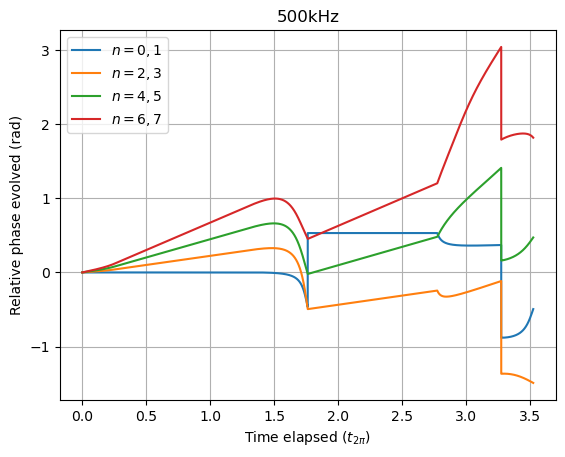

In [368]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

MDFE = gen_MDFEdown_seq(free_time=pi/(4*dR) - (0*0.039286*pi/(2*dR)), rabi_freq=rabi_freq, time_steps=n_steps)

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    pulse_seq1 = PulseSequence()

    pulse1 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)
    pulse2 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/2)

    free = FreeEvolution(laser_det=(np.full(n_steps, -dR)), duration=(pi/(0.5*dR) - (1.8*0.039286*pi/(4*dR))))
    detuning = omega_eg/2
    free_time = 2*pi/(np.abs(dR-detuning))
    # free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((9.83*free_time/16)))
    free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((5*free_time/8)))
    

    pulse_seq1.add_pulses([pulse1, MDFE, free2, pulse1])

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

fig, ax = plt.subplots()
ax.plot(times/(rabi_time),angles.transpose()/pi)
# ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.grid()
ax.set_ylabel(r'Relative phase evolved (rad)')
ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'])
ax.set_title('500kHz')
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)


print(angles[:,-1]/pi)





# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

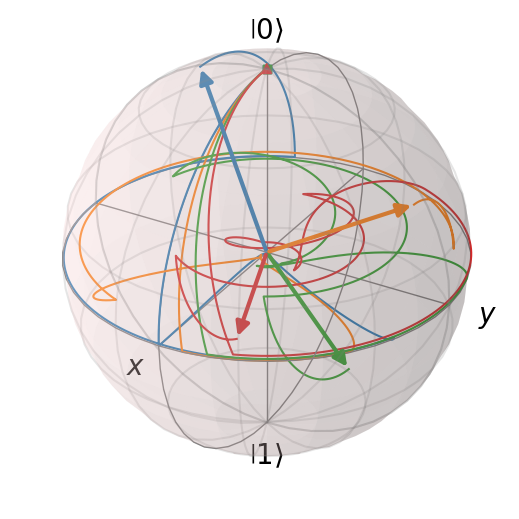

In [369]:
plot_bloch_multi(wave_func=wave_funcs, show=False)

[ 0.12380895 -1.38452235 -0.90835118 -0.45587216]


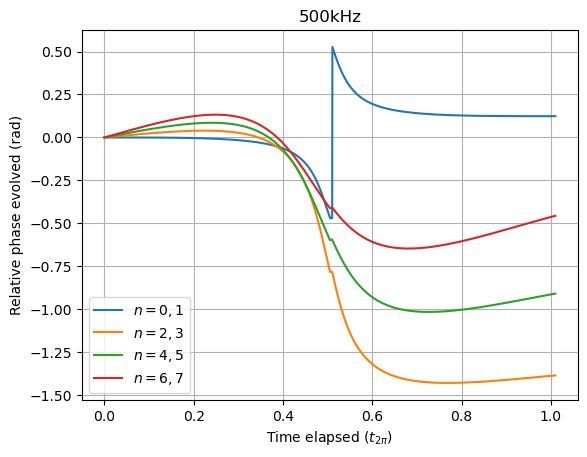

In [392]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

MDFE = gen_MDFEdown_seq(free_time=0.01*pi/(8*dR), rabi_freq=rabi_freq, time_steps=n_steps)

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    pulse_seq1 = PulseSequence()

    pulse1 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)
    pulse2 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/2)

    free = FreeEvolution(laser_det=(np.full(n_steps, -dR)), duration=(pi/(0.5*dR) - (1.8*0.039286*pi/(4*dR))))
    detuning = omega_eg/2
    free_time = 2*pi/(np.abs(dR-detuning))
    # free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((9.83*free_time/16)))
    free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((5*free_time/8)))
    

    pulse_seq1.add_pulses([MDFE])

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

fig, ax = plt.subplots()
ax.plot(times/(rabi_time),angles.transpose()/pi)
# ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.grid()
ax.set_ylabel(r'Relative phase evolved (rad)')
ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'])
ax.set_title('500kHz')
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)


print(angles[:,-1]/pi)





# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

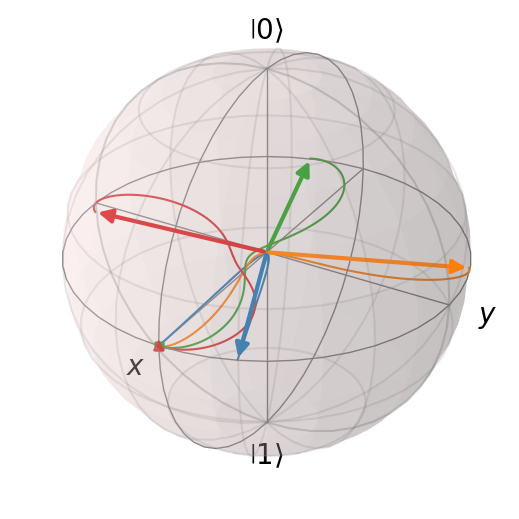

In [393]:
plot_bloch_multi(wave_func=wave_funcs, show=False)

[0.03928551 0.07840097 0.11718576]


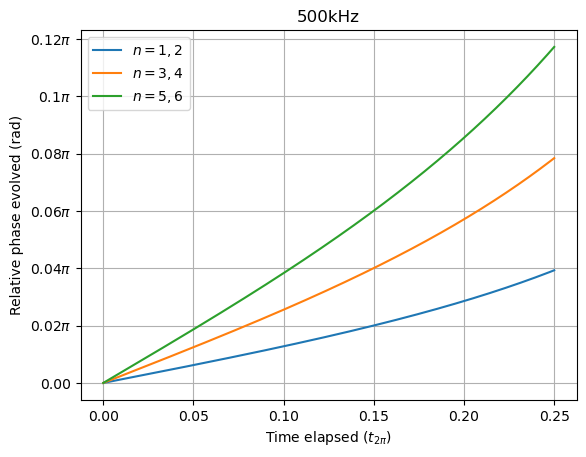

In [106]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [9,11,13]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

# MDFE = gen_MDFEdown_seq(free_time=0.039286*pi/(4*dR), rabi_freq=rabi_freq*1e5, time_steps=n_steps)

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    pulse_seq1 = PulseSequence()

    pulse1 = DownPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, -pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)

    # detuning = 40*dR
    # free_time = 2*pi/(np.abs(dR-detuning))
    # free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(free_time/2))

    pulse_seq1.add_pulses([pulse1])

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

fig, ax = plt.subplots()
ax.plot(times/(rabi_time),angles.transpose()/pi)
ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.grid()
ax.set_ylabel(r'Relative phase evolved (rad)')
ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
ax.legend([r'$n=1,2$',r'$n=3,4$',r'$n=5,6$'])
ax.set_title('500kHz')
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)


print(angles[:,-1]/pi)





# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

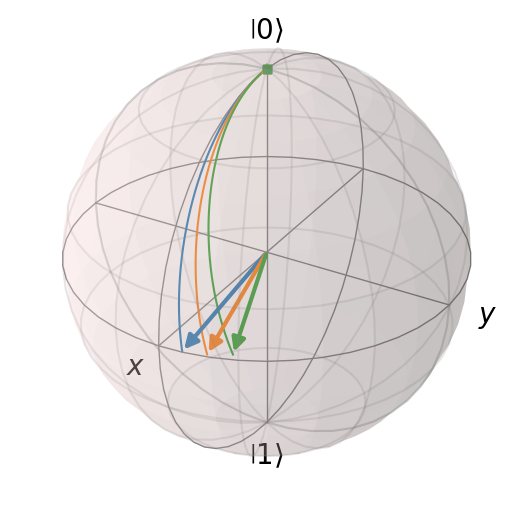

In [105]:
plot_bloch_multi(wave_func=wave_funcs, show=False)

#### Rabi scan

[-6.12323400e-17  6.07004562e-01  1.16452539e+00  1.66471005e+00]


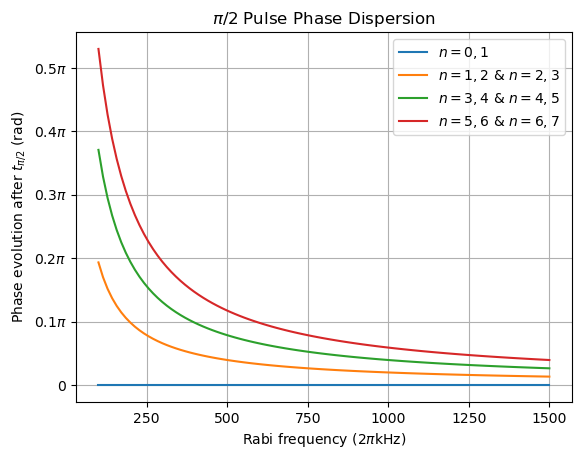

In [148]:

# Rabi frequency in 2*pi*Hz units
# rabi_freq = 2*pi*5e5
# rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

# MDFE = gen_MDFEdown_seq(free_time=0.039286*pi/(4*dR), rabi_freq=rabi_freq*1e5, time_steps=n_steps)
rabis = 2*pi*np.logspace(5,6.7,num=100,base=10)
rabis = 2*pi*np.linspace(1e5,1.5e6,100)
phases = np.zeros((len(indices),len(rabis)))

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    
    for r, rabi in enumerate(rabis):
        rabi_time = 2*pi/rabi
        pulse_seq1 = PulseSequence()
        if indices[i] % 2 ==0:
            pulse1 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi), duration=rabi_time/4)
        else:
            pulse1 = DownPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, -pi/2), rabi_freq=np.full(n_steps,rabi), duration=rabi_time/4)
        # detuning = 40*dR
        # free_time = 2*pi/(np.abs(dR-detuning))
        # free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(free_time/2))

        pulse_seq1.add_pulses([pulse1])

        wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

        

        phases[i,r] = (np.angle(wave_func[-1,indices[i]+1]) - np.angle(wave_func[-1,indices[i]]))

    phases[i,:] = np.unwrap(phases[i,:])

phases[-1,:] = phases[-1,:] + 2*pi


fig, ax = plt.subplots()
ax.plot(rabis/(2*pi*1e3),phases.transpose()/pi)
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5],[r'0', r'0.1$\pi$', r'0.2$\pi$', r'0.3$\pi$', r'0.4$\pi$', r'0.5$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.set_xticks(np.linspace(250,1500,6))
ax.grid()
ax.set_ylabel(r'Phase evolution after $t_{\pi/2}$ (rad)')
ax.set_xlabel(r'Rabi frequency ($2\pi$kHz)')
ax.legend([r'$n=0,1$',r'$n=1,2$ & $n=2,3$',r'$n=3,4$ & $n=4,5$',r'$n=5,6$ & $n=6,7$'])
ax.set_title(r'$\pi/2$ Pulse Phase Dispersion');
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)


# print(angles[:,-1]/pi)


print(phases[:,0])


# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)